# PCOS — Tech Challenge Fase 1 (Notebook Consolidado)

Pipeline **de ponta a ponta** para detecção de Síndrome dos Ovários Policísticos (SOP/PCOS):
**exploração → pré-processamento → modelagem → avaliação → explicabilidade**.


In [3]:
# =============================================================================
# FASE 0 — SETUP: imports e função utilitária de log
# =============================================================================
# No Colab, descomente as linhas abaixo se algum pacote faltar:
#!pip install -q shap openpyxl kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

def log(msg, nivel=0):
    """Log simples para narrar as fases do processo."""
    prefixo = {0: "", 1: "  -> ", 2: "     . "}.get(nivel, "")
    print(f"{prefixo}{msg}")

log("Ambiente pronto. Bibliotecas importadas.")


Ambiente pronto. Bibliotecas importadas.


In [4]:
# =============================================================================
# FASE 1 — CARGA DOS DADOS BRUTOS
# =============================================================================
# O dataset PCOS vem em Excel; os dados completos estão na aba "Full_new".
# Opção A (local): arquivo já baixado do Kaggle.
# Opção B (Colab): use kagglehub para baixar (descomente abaixo).

# import kagglehub, glob, os
# caminho_kaggle = kagglehub.dataset_download("prasoonkottarathil/polycystic-ovary-syndrome-pcos")
# ARQUIVO = glob.glob(os.path.join(caminho_kaggle, "**", "*without*infertility*.xlsx"), recursive=True)[0]

ARQUIVO = "../datasets/PCOS_data_without_infertility.xlsx"

log("FASE 1 — Carregando dados brutos...")
df = pd.read_excel(ARQUIVO, sheet_name="Full_new")
log(f"Arquivo lido: {ARQUIVO}", 1)
log(f"Shape inicial: {df.shape[0]} pacientes x {df.shape[1]} colunas", 1)
df.head(3)


FASE 1 — Carregando dados brutos...
  -> Arquivo lido: ../datasets/PCOS_data_without_infertility.xlsx
  -> Shape inicial: 541 pacientes x 45 colunas


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN


In [5]:
# =============================================================================
# FASE 2 — INVESTIGAÇÃO / DIAGNÓSTICO DE QUALIDADE (o "olhar do analista")
# =============================================================================
# Objetivo: descobrir problemas ANTES de limpar. Não confiamos cegamente nos dados.

log("FASE 2 — Diagnóstico de qualidade dos dados")

# 2.1 Tipos e nulos de forma resumida
log("2.1 Tipos de dados e valores não-nulos:", 1)
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nao_nulos": df.notna().sum(),
    "nulos": df.isna().sum(),
})
# Mostra apenas colunas com nulos OU que são texto (object) = potenciais problemas
suspeitas = info[(info["nulos"] > 0) | (info["dtype"] == "object")]
print(suspeitas.to_string())

# 2.2 Colunas de exame que vieram como TEXTO (object) não deveriam ser texto
cols_texto = df.select_dtypes(include="object").columns.tolist()
log(f"2.2 Colunas do tipo texto (suspeitas): {cols_texto}", 1)

# 2.3 Caça ao valor inválido: por que essas colunas são texto?
log("2.3 Procurando os valores que 'sujam' as colunas numéricas:", 1)
for col in cols_texto:
    convertido = pd.to_numeric(df[col], errors="coerce")
    mask = convertido.isna() & df[col].notna()      # falhou na conversão mas não era NaN
    if mask.any():
        valores = df.loc[mask, col].unique()
        log(f"'{col}': valor(es) inválido(s) = {list(valores)} ({mask.sum()} linha(s))", 2)

# 2.4 Colunas quase vazias (candidatas a remoção)
log("2.4 Colunas com muitos nulos (>50%):", 1)
muito_vazias = info[info["nulos"] > len(df) * 0.5].index.tolist()
log(f"{muito_vazias}", 2)

# 2.5 Colunas de identificação (não são features)
log("2.5 Colunas de ID detectadas (numeração sequencial, sem valor preditivo):", 1)
log("['Sl. No', 'Patient File No.']", 2)


FASE 2 — Diagnóstico de qualidade dos dados
  -> 2.1 Tipos de dados e valores não-nulos:
                          dtype  nao_nulos  nulos
Marraige Status (Yrs)   float64        540      1
II    beta-HCG(mIU/mL)   object        541      0
AMH(ng/mL)               object        541      0
Fast food (Y/N)         float64        540      1
Unnamed: 44              object          2    539
  -> 2.2 Colunas do tipo texto (suspeitas): ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)', 'Unnamed: 44']
  -> 2.3 Procurando os valores que 'sujam' as colunas numéricas:
     . 'II    beta-HCG(mIU/mL)': valor(es) inválido(s) = ['1.99.'] (1 linha(s))
     . 'AMH(ng/mL)': valor(es) inválido(s) = ['a'] (1 linha(s))
     . 'Unnamed: 44': valor(es) inválido(s) = ['.'] (1 linha(s))
  -> 2.4 Colunas com muitos nulos (>50%):
     . ['Unnamed: 44']
  -> 2.5 Colunas de ID detectadas (numeração sequencial, sem valor preditivo):
     . ['Sl. No', 'Patient File No.']


In [6]:
# =============================================================================
# FASE 3 — PRÉ-PROCESSAMENTO / LIMPEZA
# =============================================================================
log("FASE 3 — Limpeza dos dados (aplicando as correções da investigação)")

linhas0, cols0 = df.shape

# 3.1 Limpar nomes das colunas (remover espaços extras no início/fim)
df.columns = df.columns.str.strip()
log("3.1 Nomes das colunas normalizados (strip de espaços).", 1)

# 3.2 Remover colunas irrelevantes: IDs e coluna vazia 'Unnamed: 44'
cols_remover = ["Sl. No", "Patient File No.", "Unnamed: 44"]
df = df.drop(columns=[c for c in cols_remover if c in df.columns], errors="ignore")
log(f"3.2 Colunas removidas (IDs + vazia): {cols_remover}", 1)

# 3.3 Corrigir tipos: converter colunas de exame para numérico.
# 'coerce' transforma valores inválidos (ex.: '1.99.', 'a') em NaN, que tratamos a seguir.
cols_corrigir = ["II    beta-HCG(mIU/mL)", "AMH(ng/mL)"]
for col in cols_corrigir:
    if col in df.columns:
        antes_nulos = df[col].isna().sum()
        df[col] = pd.to_numeric(df[col], errors="coerce")
        novos_nulos = df[col].isna().sum() - antes_nulos
        log(f"3.3 '{col}' -> numérico ({novos_nulos} valor(es) inválido(s) viraram NaN).", 1)

# 3.4 Tratar valores ausentes: imputação pela MEDIANA
# Escolhemos mediana (e não média) por ser robusta a outliers, comuns em exames hormonais.
nulos_antes = int(df.isna().sum().sum())
for col in df.columns:
    if df[col].isna().any():
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
log(f"3.4 Valores ausentes imputados pela mediana (havia {nulos_antes} nulos, agora 0).", 1)

log(f"Resumo: de ({linhas0}x{cols0}) para ({df.shape[0]}x{df.shape[1]}). "
    f"Nulos restantes: {int(df.isna().sum().sum())}. "
    f"Colunas texto restantes: {len(df.select_dtypes(include='object').columns)}.", 1)


FASE 3 — Limpeza dos dados (aplicando as correções da investigação)
  -> 3.1 Nomes das colunas normalizados (strip de espaços).
  -> 3.2 Colunas removidas (IDs + vazia): ['Sl. No', 'Patient File No.', 'Unnamed: 44']
  -> 3.3 'II    beta-HCG(mIU/mL)' -> numérico (1 valor(es) inválido(s) viraram NaN).
  -> 3.3 'AMH(ng/mL)' -> numérico (1 valor(es) inválido(s) viraram NaN).
  -> 3.4 Valores ausentes imputados pela mediana (havia 4 nulos, agora 0).
  -> Resumo: de (541x45) para (541x42). Nulos restantes: 0. Colunas texto restantes: 0.


FASE 4 — EDA: estatísticas descritivas, distribuição do alvo e correlações
  -> 4.1 Estatísticas descritivas (primeiras features):
                  count    mean    std     min     25%     50%     75%    max
PCOS (Y/N)        541.0    0.33   0.47    0.00    0.00    0.00    1.00    1.0
Age (yrs)         541.0   31.43   5.41   20.00   28.00   31.00   35.00   48.0
Weight (Kg)       541.0   59.64  11.03   31.00   52.00   59.00   65.00  108.0
Height(Cm)        541.0  156.48   6.03  137.00  152.00  156.00  160.00  180.0
BMI               541.0   24.31   4.06   12.42   21.64   24.24   26.63   38.9
Blood Group       541.0   13.80   1.84   11.00   13.00   14.00   15.00   18.0
Pulse rate(bpm)   541.0   73.25   4.43   13.00   72.00   72.00   74.00   82.0
RR (breaths/min)  541.0   19.24   1.69   16.00   18.00   18.00   20.00   28.0
Hb(g/dl)          541.0   11.16   0.87    8.50   10.50   11.00   11.70   14.8
Cycle(R/I)        541.0    2.56   0.90    2.00    2.00    2.00    4.00    5.0
  -> 4.2 Di

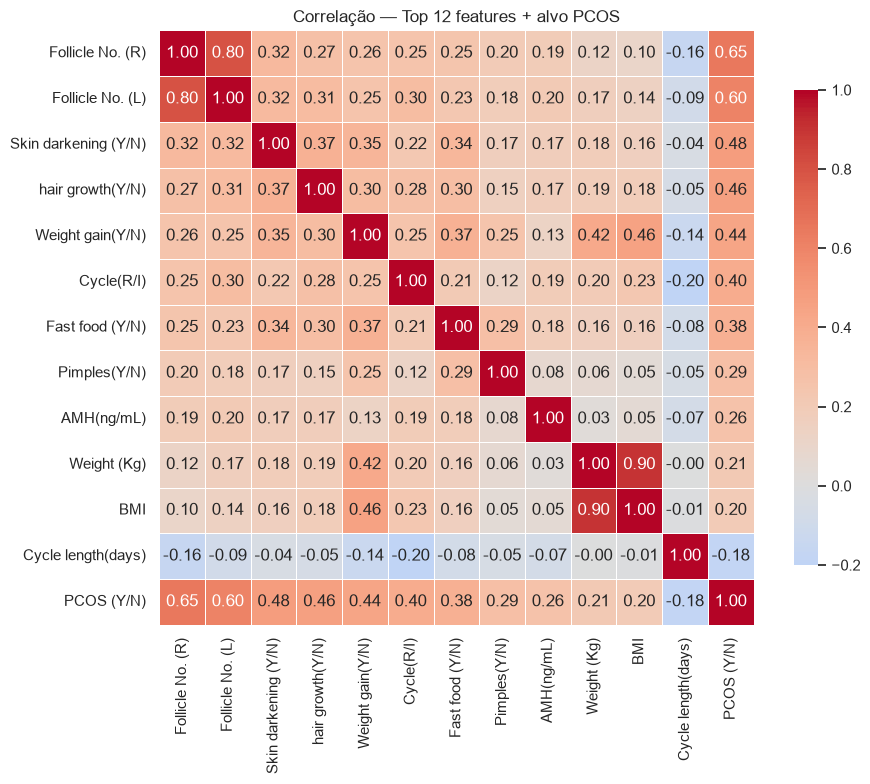

     . 4.4 Heatmap gerado. Ex.: nº de folículos, ganho de peso e ciclo tendem a se destacar -> coerente com o quadro clínico de SOP.


In [7]:
# =============================================================================
# FASE 4 — ANÁLISE EXPLORATÓRIA: ESTATÍSTICAS, DISTRIBUIÇÕES E CORRELAÇÃO
# =============================================================================
log("FASE 4 — EDA: estatísticas descritivas, distribuição do alvo e correlações")

TARGET = "PCOS (Y/N)"

# 4.1 Estatísticas descritivas (resumo)
log("4.1 Estatísticas descritivas (primeiras features):", 1)
print(df.describe().T.head(10).round(2).to_string())

# 4.2 Distribuição do alvo (checar balanceamento)
cont = df[TARGET].value_counts()
prop = df[TARGET].value_counts(normalize=True).mul(100).round(1)
log("4.2 Distribuição do alvo PCOS (0=Não, 1=Sim):", 1)
log(f"Contagem: {cont.to_dict()} | Proporção(%): {prop.to_dict()}", 2)
log(f"Classe desbalanceada (~{prop.get(1,0):.0f}% positivos) -> priorizar Recall/F1 "
    f"e usar stratify no split.", 2)

# 4.3 Análise de correlação com o alvo (top features)
log("4.3 Features mais correlacionadas com PCOS (|correlação|):", 1)
corr = df.corr(numeric_only=True)
corr_target = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print(corr_target.head(10).round(3).to_string())

# 4.4 Heatmap das top features + alvo (padrões relevantes)
top_feats = corr_target.head(12).index.tolist() + [TARGET]
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlação — Top 12 features + alvo PCOS")
plt.tight_layout()
plt.show()
log("4.4 Heatmap gerado. Ex.: nº de folículos, ganho de peso e ciclo tendem a se destacar "
    "-> coerente com o quadro clínico de SOP.", 2)


In [8]:
# =============================================================================
# FASE 5 — EXPORTAR DATASET LIMPO (pcos_clean.csv)
# =============================================================================
# Importante: salvamos SEM escalonar (valores reais/interpretáveis).
# O escalonamento acontece dentro do pipeline de treino (Fase 6), evitando data leakage.
log("FASE 5 — Exportando dataset limpo")
df.to_csv("../datasets/pcos_clean.csv", index=False)
log(f"'pcos_clean.csv' salvo: {df.shape[0]} linhas x {df.shape[1]} colunas, "
    f"0 nulos, 100% numérico.", 1)


FASE 5 — Exportando dataset limpo
  -> 'pcos_clean.csv' salvo: 541 linhas x 42 colunas, 0 nulos, 100% numérico.


In [9]:
# =============================================================================
# FASE 6 — MODELAGEM: separação treino/teste (com estratificação)
# =============================================================================
log("FASE 6 — Preparando X/y e separando treino/teste")

X = df.drop(columns=[TARGET])
y = df[TARGET]
log(f"X: {X.shape[1]} features | y: alvo '{TARGET}'", 1)

# stratify=y mantém a proporção 67/33 nos dois conjuntos; random_state garante reprodutibilidade.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
log(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}", 1)
log(f"Proporção de positivos -> treino: {y_train.mean()*100:.1f}% | "
    f"teste: {y_test.mean()*100:.1f}% (equilibradas pelo stratify)", 2)

def criar_pipeline(modelo):
    """StandardScaler + modelo. O scaler faz fit só no treino (dentro do pipeline) -> sem leakage.
    Modelos de árvore não precisam de escala, mas o scaler não os prejudica."""
    return Pipeline([("scaler", StandardScaler()), ("model", modelo)])


FASE 6 — Preparando X/y e separando treino/teste
  -> X: 41 features | y: alvo 'PCOS (Y/N)'
  -> Treino: 432 | Teste: 109
     . Proporção de positivos -> treino: 32.6% | teste: 33.0% (equilibradas pelo stratify)


In [10]:
# =============================================================================
# FASE 7 — TREINAR MÚLTIPLOS MODELOS (enunciado pede 2+; usamos 4 p/ comparar)
# =============================================================================
log("FASE 7 — Treinando e avaliando 4 modelos de classificação")

modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

resultados = {}
for nome, modelo in modelos.items():
    pipe = criar_pipeline(modelo)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    resultados[nome] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "_pipe": pipe, "_pred": y_pred, "_proba": y_proba,
    }
    log(f"{nome}: Acc={resultados[nome]['Accuracy']:.3f} | "
        f"Recall={resultados[nome]['Recall']:.3f} | F1={resultados[nome]['F1']:.3f}", 1)


FASE 7 — Treinando e avaliando 4 modelos de classificação
  -> KNN: Acc=0.899 | Recall=0.722 | F1=0.825
  -> Árvore de Decisão: Acc=0.890 | Recall=0.806 | F1=0.829
  -> Random Forest: Acc=0.899 | Recall=0.778 | F1=0.836
  -> Regressão Logística: Acc=0.890 | Recall=0.861 | F1=0.838


FASE 8 — Comparando modelos (ordenado por Recall, depois F1)
                     Accuracy  Precision  Recall     F1    AUC
Regressão Logística     0.890      0.816   0.861  0.838  0.951
Árvore de Decisão       0.890      0.853   0.806  0.829  0.869
Random Forest           0.899      0.903   0.778  0.836  0.948
KNN                     0.899      0.963   0.722  0.825  0.937
  -> Melhor por Recall: Regressão Logística (Recall=0.861, F1=0.838)


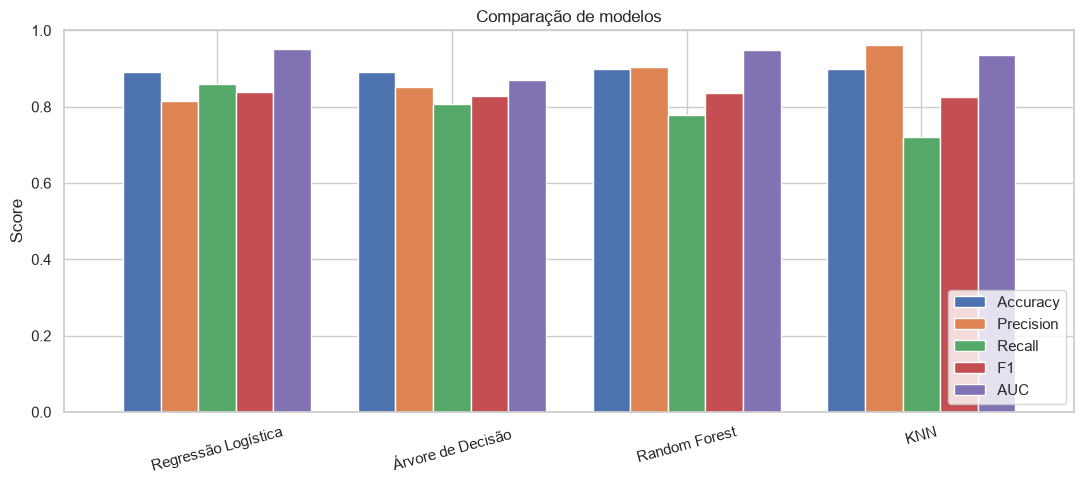

In [11]:
# =============================================================================
# FASE 8 — COMPARAÇÃO E ESCOLHA DA MÉTRICA
# =============================================================================
# Discussão da métrica (exigida pelo enunciado):
# Em diagnóstico médico, o pior erro é o FALSO NEGATIVO (dizer que a paciente NÃO tem
# PCOS quando ela TEM) -> diagnóstico perdido. Por isso priorizamos RECALL da classe
# positiva, com F1 como equilíbrio. Accuracy sozinha engana com classes desbalanceadas.
log("FASE 8 — Comparando modelos (ordenado por Recall, depois F1)")

metricas = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
tabela = pd.DataFrame({n: {m: resultados[n][m] for m in metricas} for n in resultados}).T
tabela = tabela.sort_values(["Recall", "F1"], ascending=False).round(3)
print(tabela.to_string())

melhor_nome = tabela.index[0]
log(f"Melhor por Recall: {melhor_nome} "
    f"(Recall={tabela.loc[melhor_nome,'Recall']:.3f}, F1={tabela.loc[melhor_nome,'F1']:.3f})", 1)

# Gráfico comparativo
tabela[metricas].plot(kind="bar", figsize=(11, 5), width=0.8)
plt.title("Comparação de modelos"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=15); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()


FASE 9 — Matrizes de confusão e curva ROC
  -> KNN: Falsos Negativos (diagnósticos perdidos) = 10
  -> Árvore de Decisão: Falsos Negativos (diagnósticos perdidos) = 7
  -> Random Forest: Falsos Negativos (diagnósticos perdidos) = 8
  -> Regressão Logística: Falsos Negativos (diagnósticos perdidos) = 5


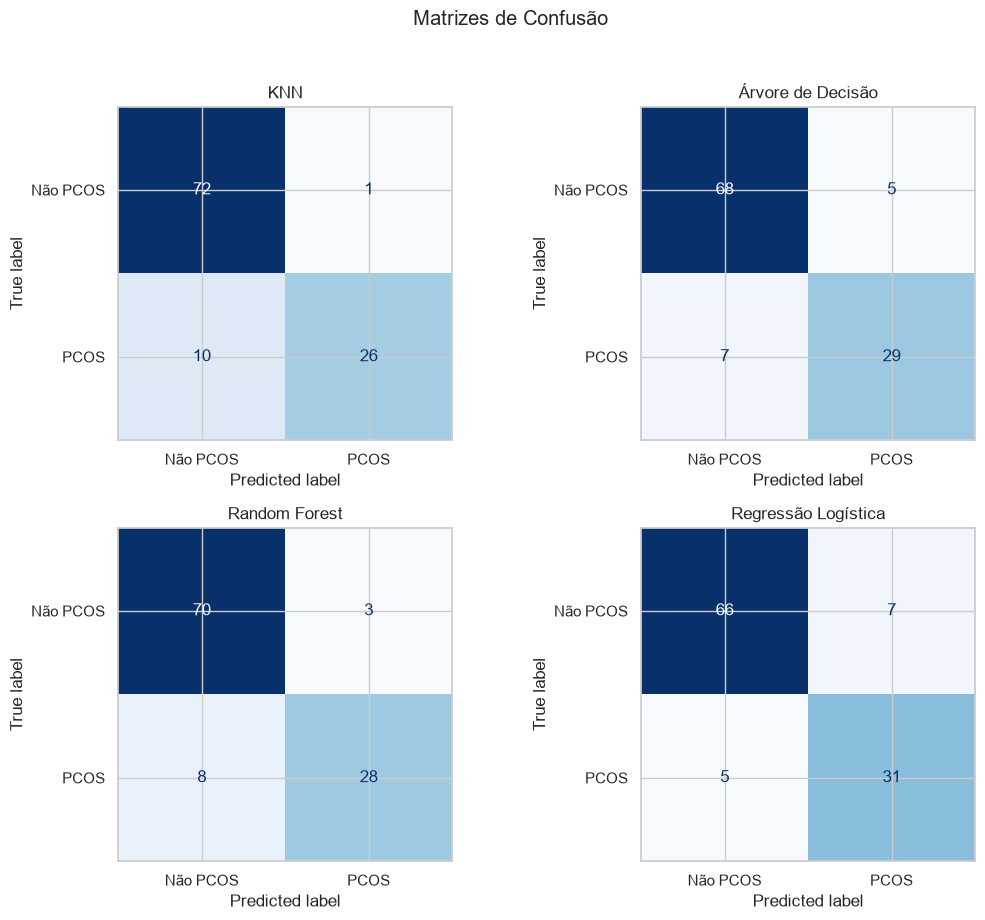

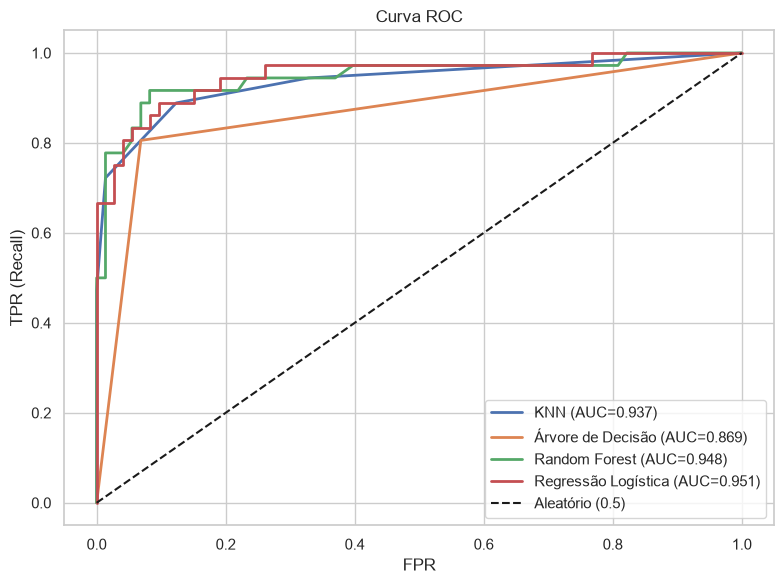

In [12]:
# =============================================================================
# FASE 9 — MATRIZ DE CONFUSÃO E CURVA ROC
# =============================================================================
log("FASE 9 — Matrizes de confusão e curva ROC")

# Matrizes de confusão (foco no FN = canto inferior esquerdo)
fig, axes = plt.subplots(2, 2, figsize=(11, 9)); axes = axes.ravel()
for ax, nome in zip(axes, resultados):
    cm = confusion_matrix(y_test, resultados[nome]["_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Não PCOS", "PCOS"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)
    fn = cm[1, 0]  # real=PCOS, previsto=Não  -> falso negativo
    log(f"{nome}: Falsos Negativos (diagnósticos perdidos) = {fn}", 1)
plt.suptitle("Matrizes de Confusão", y=1.02); plt.tight_layout(); plt.show()

# Curva ROC
plt.figure(figsize=(8, 6))
for nome in resultados:
    fpr, tpr, _ = roc_curve(y_test, resultados[nome]["_proba"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC={resultados[nome]['AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Aleatório (0.5)")
plt.xlabel("FPR"); plt.ylabel("TPR (Recall)"); plt.title("Curva ROC")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# FASE 10 — TUNING DE HIPERPARÂMETROS (2 modelos, otimizando RECALL)
# =============================================================================
log("FASE 10 — Otimização de hiperparâmetros com GridSearchCV (scoring=recall)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# n_jobs=1 evita erros de multiprocessing em alguns ambientes (Windows/Python).
# Se o ambiente estiver ok e quiser acelerar, troque para n_jobs=-1.

# 10.1 Random Forest
# model n estimators = número de árvores; max_depth = profundidade máxima; min_samples_split = min. amostras p/ dividir nó.
grid_rf = GridSearchCV(
    criar_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
    {"model__n_estimators": [100, 200], "model__max_depth": [None, 5, 10],
     "model__min_samples_split": [2, 5]},
    scoring="recall", cv=cv, n_jobs=1)
grid_rf.fit(X_train, y_train)
rf_tunado = grid_rf.best_estimator_
y_pred_rf = rf_tunado.predict(X_test)
log(f"10.1 Random Forest -> melhores params: {grid_rf.best_params_}", 1)
log(f"Recall(teste)={recall_score(y_test,y_pred_rf):.3f} | F1={f1_score(y_test,y_pred_rf):.3f}", 2)

# 10.2 Regressão Logística
#model C é a força de regularização (quanto menor, mais regularização). O solver 'liblinear' é bom para datasets pequenos.
grid_lr = GridSearchCV(
    criar_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    {"model__C": [0.01, 0.1, 1, 10, 100], "model__solver": ["lbfgs", "liblinear"]},
    scoring="recall", cv=cv, n_jobs=1)
grid_lr.fit(X_train, y_train)
lr_tunado = grid_lr.best_estimator_
y_pred_lr = lr_tunado.predict(X_test)
log(f"10.2 Regressão Logística -> melhores params: {grid_lr.best_params_}", 1)
log(f"Recall(teste)={recall_score(y_test,y_pred_lr):.3f} | F1={f1_score(y_test,y_pred_lr):.3f}", 2)

# 10.3 Escolha do modelo final (maior Recall)
cand = {
    "Random Forest (tunada)": (rf_tunado, y_pred_rf, recall_score(y_test, y_pred_rf)),
    "Reg. Logística (tunada)": (lr_tunado, y_pred_lr, recall_score(y_test, y_pred_lr)),
}
modelo_final_nome = max(cand, key=lambda k: cand[k][2])
modelo_final, y_pred_final, _ = cand[modelo_final_nome]
log(f"10.3 Modelo FINAL escolhido (maior Recall): {modelo_final_nome}", 1)
print("\nRelatório do modelo final no teste:")
print(classification_report(y_test, y_pred_final, target_names=["Não PCOS (0)", "PCOS (1)"]))


FASE 10 — Otimização de hiperparâmetros com GridSearchCV (scoring=recall)
  -> 10.1 Random Forest -> melhores params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
     . Recall(teste)=0.778 | F1=0.848
  -> 10.2 Regressão Logística -> melhores params: {'model__C': 0.01, 'model__solver': 'liblinear'}
     . Recall(teste)=0.917 | F1=0.880
  -> 10.3 Modelo FINAL escolhido (maior Recall): Reg. Logística (tunada)

Relatório do modelo final no teste:
              precision    recall  f1-score   support

Não PCOS (0)       0.96      0.92      0.94        73
    PCOS (1)       0.85      0.92      0.88        36

    accuracy                           0.92       109
   macro avg       0.90      0.92      0.91       109
weighted avg       0.92      0.92      0.92       109



FASE 11 — Importância das features do modelo final


C:\Users\fabar\AppData\Local\Temp\ipykernel_20040\1993854778.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette="viridis")


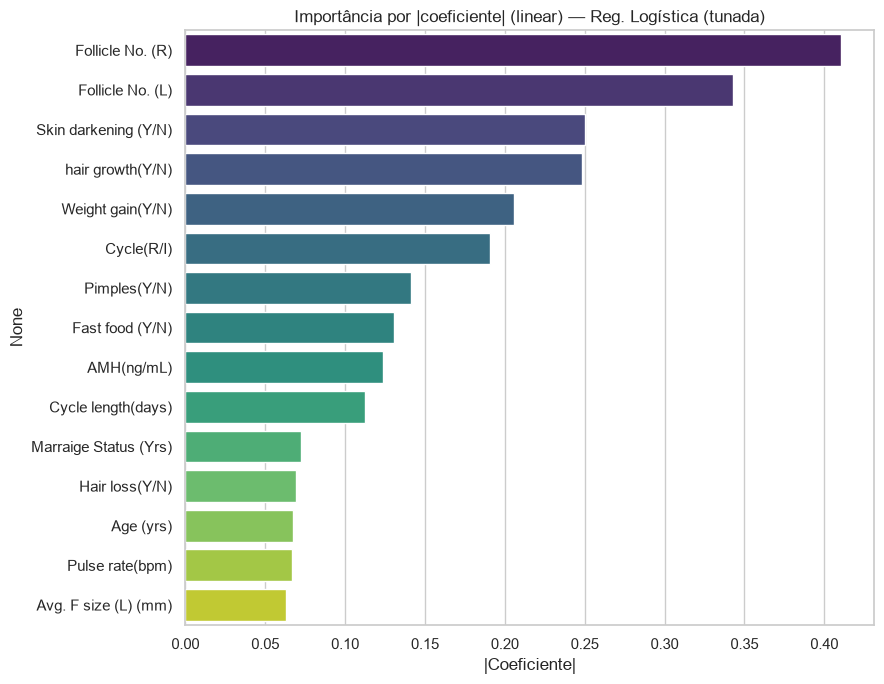

  -> Top 5 features mais influentes:
     . Follicle No. (R): 0.411
     . Follicle No. (L): 0.343
     . Skin darkening (Y/N): 0.250
     . hair growth(Y/N): 0.248
     . Weight gain(Y/N): 0.205
  -> Validação clínica: se folículos, AMH, ganho de peso e ciclo aparecem no topo, o modelo aprendeu padrões coerentes com SOP (bom sinal).


In [14]:
# =============================================================================
# FASE 11 — EXPLICABILIDADE I: Feature Importance / Coeficientes
# =============================================================================
log("FASE 11 — Importância das features do modelo final")

modelo_step = modelo_final.named_steps["model"]
if hasattr(modelo_step, "feature_importances_"):
    imp = pd.Series(modelo_step.feature_importances_, index=X.columns)
    titulo, xlab = "Feature Importance (árvore)", "Importância"
else:
    # Modelo linear: usamos |coeficiente| como importância
    imp = pd.Series(np.abs(modelo_step.coef_[0]), index=X.columns)
    titulo, xlab = "Importância por |coeficiente| (linear)", "|Coeficiente|"

top15 = imp.sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 7))
sns.barplot(x=top15.values, y=top15.index, palette="viridis")
plt.title(f"{titulo} — {modelo_final_nome}"); plt.xlabel(xlab); plt.tight_layout(); plt.show()

log("Top 5 features mais influentes:", 1)
for f, v in top15.head(5).items():
    log(f"{f}: {v:.3f}", 2)
log("Validação clínica: se folículos, AMH, ganho de peso e ciclo aparecem no topo, "
    "o modelo aprendeu padrões coerentes com SOP (bom sinal).", 1)


FASE 12 — SHAP (explicabilidade das previsões)


Background dataset has 109 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=109 when initializing the masker.


  -> Usando LinearExplainer (modelo linear).
  -> SHAP values calculados. Formato: (109, 41)


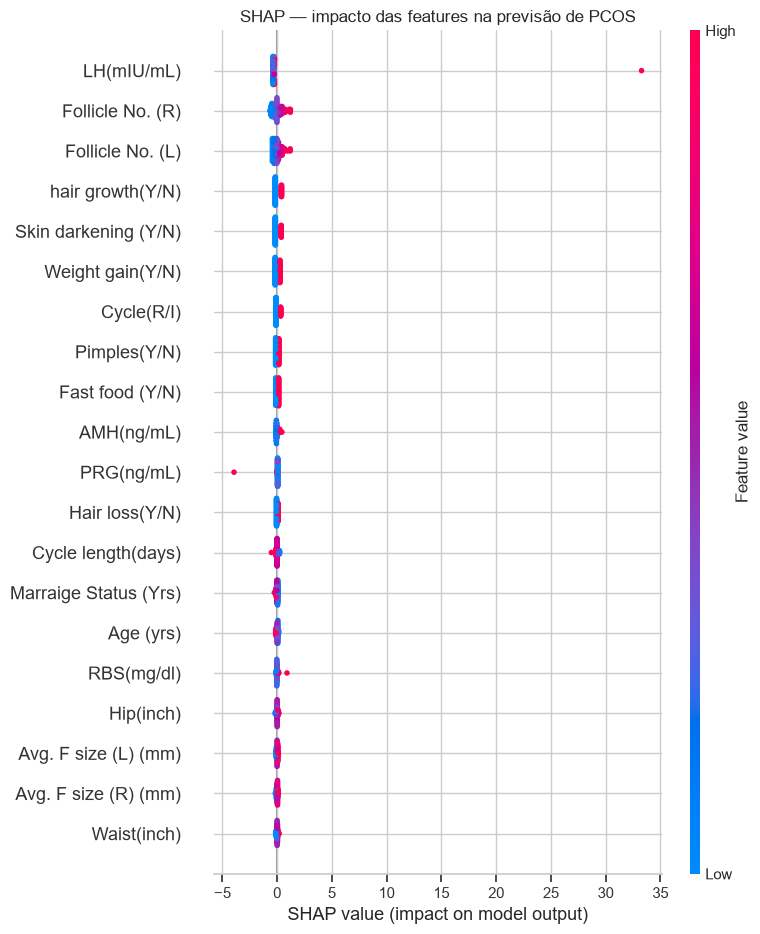

  -> No summary plot: pontos à direita empurram para PCOS=Sim; cor = valor alto(vermelho)/baixo(azul).


In [15]:
# =============================================================================
# FASE 12 — EXPLICABILIDADE II: SHAP
# =============================================================================
log("FASE 12 — SHAP (explicabilidade das previsões)")
import shap

# Escolhe o explainer conforme o tipo do modelo final
if hasattr(modelo_step, "feature_importances_"):
    explainer = shap.TreeExplainer(modelo_step)
    X_exp = X_test
    log("Usando TreeExplainer (modelo de árvore).", 1)
else:
    # LinearExplainer precisa dos dados escalonados (mesmo scaler do pipeline)
    scaler = modelo_final.named_steps["scaler"]
    X_exp = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
    explainer = shap.LinearExplainer(modelo_step, X_exp)
    log("Usando LinearExplainer (modelo linear).", 1)

shap_values = explainer.shap_values(X_exp)
# Normaliza para a classe positiva (PCOS=1), compatível entre versões do SHAP
if isinstance(shap_values, list):
    shap_pcos = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_pcos = shap_values[:, :, 1]
else:
    shap_pcos = shap_values
log(f"SHAP values calculados. Formato: {np.array(shap_pcos).shape}", 1)

shap.summary_plot(shap_pcos, X_exp, show=False)
plt.title("SHAP — impacto das features na previsão de PCOS")
plt.tight_layout(); plt.show()
log("No summary plot: pontos à direita empurram para PCOS=Sim; cor = valor alto(vermelho)/baixo(azul).", 1)


In [16]:
# =============================================================================
# FASE 13 — SALVAR MODELO E DISCUSSÃO CRÍTICA
# =============================================================================
import joblib
joblib.dump(modelo_final, "modelo_pcos_final.pkl")
log("FASE 13 — Modelo final (pipeline completo) salvo em 'modelo_pcos_final.pkl'.")

# Verificação: recarrega e prevê
mod = joblib.load("modelo_pcos_final.pkl")
log(f"Reteste após recarregar -> Acurácia: {accuracy_score(y_test, mod.predict(X_test)):.3f}", 1)

# Discussão crítica (exigida pelo enunciado):
print("""
------------------------------------------------------------------------------
DISCUSSÃO CRÍTICA
------------------------------------------------------------------------------
- O modelo pode ser usado na PRÁTICA? Sim, como ferramenta de APOIO/triagem: ajuda a
  priorizar pacientes com maior probabilidade de PCOS para investigação mais rápida.
- Métrica priorizada: RECALL da classe positiva, pois o erro mais grave é o falso
  negativo (deixar de identificar uma paciente que tem PCOS).
- Explicabilidade (Feature Importance + SHAP) torna a decisão auditável e alinhada
  ao conhecimento clínico, aumentando a confiança dos profissionais.
- LIMITE ÉTICO: é um sistema de apoio; o MÉDICO tem sempre a palavra final no
  diagnóstico. O modelo não substitui exames nem avaliação clínica.
- Limitações: dataset pequeno (541 pacientes) e de uma origem específica; recomenda-se
  validação externa antes de qualquer uso real.
------------------------------------------------------------------------------
""")


FASE 13 — Modelo final (pipeline completo) salvo em 'modelo_pcos_final.pkl'.
  -> Reteste após recarregar -> Acurácia: 0.917

------------------------------------------------------------------------------
DISCUSSÃO CRÍTICA
------------------------------------------------------------------------------
- O modelo pode ser usado na PRÁTICA? Sim, como ferramenta de APOIO/triagem: ajuda a
  priorizar pacientes com maior probabilidade de PCOS para investigação mais rápida.
- Métrica priorizada: RECALL da classe positiva, pois o erro mais grave é o falso
  negativo (deixar de identificar uma paciente que tem PCOS).
- Explicabilidade (Feature Importance + SHAP) torna a decisão auditável e alinhada
  ao conhecimento clínico, aumentando a confiança dos profissionais.
- LIMITE ÉTICO: é um sistema de apoio; o MÉDICO tem sempre a palavra final no
  diagnóstico. O modelo não substitui exames nem avaliação clínica.
- Limitações: dataset pequeno (541 pacientes) e de uma origem específica; recomenda-se